In [791]:
import numpy as np
import pandas as pd



# =========================
# Physics utilities
# =========================

def energy(m0, m1, m2):
    return (m0**2 + m1**2 - m2**2) / (2 * m0)

def momentum(m0, m1, m2):
    return np.sqrt(np.maximum(energy(m0, m1, m2)**2 - m1**2, 0))


# =========================
# Angular generator
# =========================

def generate_angles(n):
    theta = np.arccos(1 - 2*np.random.rand(n))  # isotropic
    phi = 2 * np.pi * np.random.rand(n)
    return theta, phi


In [792]:

# =========================
# Two-body decay generator
# =========================

def two_body_decay(n, m0, m1, m2, label):
    """
    Generates n events of m0 → m1 + m2 in rest frame
    """
    E1 = energy(m0, m1, m2)
    E2 = energy(m0, m2, m1)
    p = momentum(m0, m1, m2)

    theta, phi = generate_angles(n)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,

        "E1": E1,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E2,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df



In [793]:

# =========================
# Gamma-gamma → X (mass spectrum)
# =========================

def sample_exponential_mass(n, m_min, m_max, scale):
    """
    Exponential spectrum between m_min and m_max
    """
    masses = []
    while len(masses) < n:
        x = np.random.exponential(scale)
        if m_min <= x <= m_max:
            masses.append(x)
    return np.array(masses)


def gamma_gamma_to_pair(n, m_particle, label, scale=1.0):
    """
    γγ → particle + antiparticle with exponential invariant mass
    """
    m_min = 2 * m_particle
    m_max = 7.0  # GeV

    m0 = sample_exponential_mass(n, m_min, m_max, scale)

    theta, phi = generate_angles(n)

    E = m0 / 2
    p = np.sqrt(np.maximum(E**2 - m_particle**2, 0))

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,
        "m_inv": m0,

        "E1": E,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df  

In [794]:
def compute_kinematics(px, py, pz):
    pT = np.sqrt(px**2 + py**2)
    p = np.sqrt(px**2 + py**2 + pz**2)

    # avoid division issues
    eta = 0.5 * np.log((p + pz + 1e-12) / (p - pz + 1e-12))

    return pT, p, eta

In [795]:
def smear_momentum_realistic(df, a=0.01, b=0.01):
    """
    More realistic TPC-like smearing:
    - pT-dependent resolution
    - η dependence
    - multiple scattering at low pT
    """

    df = df.copy()

    for i in [1, 2]:
        px = df[f"px{i}"].values
        py = df[f"py{i}"].values
        pz = df[f"pz{i}"].values
        E  = df[f"E{i}"].values

        pT, p, eta = compute_kinematics(px, py, pz)

        # --- base resolution ---
        sigma_rel = np.sqrt(a**2 + (b * pT)**2)

        # --- η dependence (worse at edges of TPC) ---
        sigma_rel *= (1 + 0.3 * np.abs(eta))

        # --- multiple scattering (dominates at low pT) ---
        sigma_rel += 0.02 / np.maximum(pT, 0.1)

        # --- smear total momentum ---
        p_smeared = p * (1 + np.random.normal(0, sigma_rel))

        scale = np.where(p > 0, p_smeared / p, 1.0)

        px_new = px * scale
        py_new = py * scale
        pz_new = pz * scale

        # --- recompute energy (mass preserved) ---
        mass2 = E**2 - p**2
        new_p2 = px_new**2 + py_new**2 + pz_new**2
        E_new = np.sqrt(np.maximum(new_p2 + mass2, 0))

        df[f"px{i}"] = px_new
        df[f"py{i}"] = py_new
        df[f"pz{i}"] = pz_new
        df[f"E{i}"]  = E_new

    return df

In [796]:
def apply_acceptance(df, eta_max=0.9):
    df = df.copy()

    for i in [1, 2]:
        px = df[f"px{i}"]
        py = df[f"py{i}"]
        pz = df[f"pz{i}"]

        _, _, eta = compute_kinematics(px, py, pz)
        df[f"eta{i}"] = eta

    # keep only events where BOTH tracks are inside acceptance
    mask = (np.abs(df["eta1"]) < eta_max) & (np.abs(df["eta2"]) < eta_max)

    return df[mask]

In [797]:
def apply_bremsstrahlung(df, prob=0.3, scale=0.3):
    """
    Simulate bremsstrahlung for electrons:
    - Only affects electron channels
    - Random fractional energy loss
    """

    df = df.copy()

    # Identify electron events
    is_electron = df["process"].str.contains("ee")

    for i in [1, 2]:
        px = df[f"px{i}"].values
        py = df[f"py{i}"].values
        pz = df[f"pz{i}"].values
        E  = df[f"E{i}"].values

        p = np.sqrt(px**2 + py**2 + pz**2)

        # Decide which tracks radiate
        do_brem = (np.random.rand(len(df)) < prob) & is_electron

        # Sample fractional energy loss (heavy tail)
        frac_loss = np.random.exponential(scale, size=len(df))
        frac_loss = np.clip(frac_loss, 0, 0.9)  # avoid total energy loss

        # Apply only where bremsstrahlung happens
        loss_factor = np.ones(len(df))
        loss_factor[do_brem] -= frac_loss[do_brem]

        # Apply to momentum
        px_new = px * loss_factor
        py_new = py * loss_factor
        pz_new = pz * loss_factor

        # Recompute energy (electron mass ~ constant)
        mass2 = E**2 - p**2
        new_p2 = px_new**2 + py_new**2 + pz_new**2
        E_new = np.sqrt(np.maximum(new_p2 + mass2, 0))

        df[f"px{i}"] = px_new
        df[f"py{i}"] = py_new
        df[f"pz{i}"] = pz_new
        df[f"E{i}"]  = E_new

    return df

In [798]:
# =========================
# Masses (GeV)
# =========================

masses = {
    "Jpsi": 3.0969,
    "Psip": 3.686,
    "p": 0.938,
    "mu": 0.1057,
    "e": 0.000511,
    "K": 0.4937
}


# =========================
# Generate datasets
# =========================

N = 10000

df_list = []

# J/ψ decays
df_list.append(two_body_decay(N, masses["Jpsi"], masses["p"], masses["p"], "Jpsi→pp"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["e"], masses["e"], "Jpsi→ee"))

# ψ' decays
df_list.append(two_body_decay(N, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"))

# γγ processes
df_list.append(gamma_gamma_to_pair(N, masses["mu"], "γγ→mumu"))
df_list.append(gamma_gamma_to_pair(N, masses["e"], "γγ→ee"))
df_list.append(gamma_gamma_to_pair(N, masses["K"], "γγ→KK"))

import matplotlib as plt
# Combine everything
df = pd.concat(df_list, ignore_index=True)

# 1. Acceptance (geometry)
df = apply_acceptance(df, eta_max=0.9)

# 2. Bremsstrahlung (physics energy loss)
df = apply_bremsstrahlung(df, prob=0.3, scale=0.3)

# 3. Detector resolution (TPC smearing)
df = smear_momentum_realistic(df, a=0.01, b=0.01)

print(df.head())

   process        E1       px1       py1       pz1        E2       px2  \
1  Jpsi→pp  1.510152 -0.456050  1.082685  0.143267  1.545996  0.473548   
3  Jpsi→pp  1.491142  0.071422 -1.075531  0.426370  1.554027 -0.076341   
5  Jpsi→pp  1.588411  1.118283  0.139987  0.610780  1.541843 -1.067529   
6  Jpsi→pp  1.530036  1.056214 -0.065326 -0.584217  1.591001 -1.122881   
7  Jpsi→pp  1.558437 -1.231240 -0.058643  0.171731  1.581693  1.259930   

        py2       pz2  m_inv      eta1      eta2  
1 -1.124225 -0.148764    NaN  0.121648 -0.121648  
3  1.149621 -0.455742    NaN  0.385907 -0.385907  
5 -0.133634 -0.583060    NaN  0.518412 -0.518412  
6  0.069450  0.621092    NaN -0.527292  0.527292  
7  0.060010 -0.175732    NaN  0.138873 -0.138873  


In [799]:
m2 = (
    (df["E1"] + df["E2"])**2
    - (df["px1"] + df["px2"])**2
    - (df["py1"] + df["py2"])**2
    - (df["pz1"] + df["pz2"])**2
)

df["m_inv"] = np.sqrt(np.maximum(m2, 0))

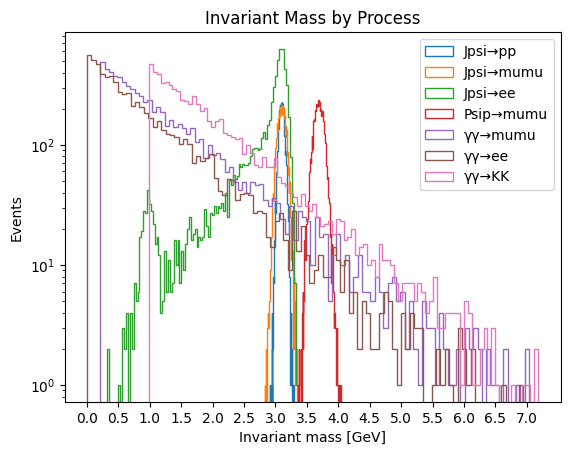

In [800]:
import matplotlib.pyplot as plt

for proc in df["process"].unique():
    subset = df[df["process"] == proc]
    plt.hist(subset["m_inv"], bins=100, histtype="step", label=proc)

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Events")
plt.xticks(np.arange(0, 7.1, 0.5))
plt.yscale('log')
plt.legend()
plt.title("Invariant Mass by Process")
plt.show()

In [801]:
def bethe_bloch(beta_gamma, params):
    """
    Stable, positive-definite Bethe-Bloch (ALICE-like empirical form)
    """
    p1, p2, p3, p4, p5 = params

    beta = beta_gamma / np.sqrt(1 + beta_gamma**2)

    # Avoid division problems
    beta = np.clip(beta, 1e-6, 0.999999)
    beta_gamma = np.clip(beta_gamma, 1e-6, None)

    term1 = p1 / (beta**p4)
    term2 = np.log(p3 + beta_gamma**p5)
    term3 = -beta**p4

    dedx = term1 * (p2 + term2 + term3)

    # Ensure strictly positive (physical floor)
    return np.maximum(dedx, 1e-6)

In [802]:
mass_map = {
    "ee": masses["e"],
    "mumu": masses["mu"],
    "KK": masses["K"],
    "pp": masses["p"]
}

In [803]:
def assign_mass(df):
    m = np.zeros(len(df))

    m[df["process"].str.contains("ee")] = masses["e"]
    m[df["process"].str.contains("mumu")] = masses["mu"]
    m[df["process"].str.contains("KK")] = masses["K"]
    m[df["process"].str.contains("pp")] = masses["p"]

    return m

In [804]:
def compute_dedx(df):
    df = df.copy()

    # ALICE-like parameters (tunable)
    params = (2.5, 0.2, 3.0, 2.0, 0.7)

    all_p = []
    all_dedx = []
    all_labels = []

    masses_per_row = assign_mass(df)

    for i in [1, 2]:
        px = df[f"px{i}"].values
        py = df[f"py{i}"].values
        pz = df[f"pz{i}"].values

        p = np.sqrt(px**2 + py**2 + pz**2)
        m = masses_per_row

        beta_gamma = p / (m + 1e-12)

        dedx = bethe_bloch(beta_gamma, params)

        # --- TPC resolution (~5–7%) ---
        resolution = 0.06
        smear = np.random.normal(0, resolution, size=len(dedx))
        dedx_smeared = dedx * (1 + smear)

        # enforce positivity after smearing
        dedx_smeared = np.maximum(dedx_smeared, 1e-6)

        all_p.append(p)
        all_dedx.append(dedx_smeared)
        all_labels.append(df["process"].values)

    return (
        np.concatenate(all_p)*1000.0,
        np.concatenate(all_dedx),
        np.concatenate(all_labels)
    )

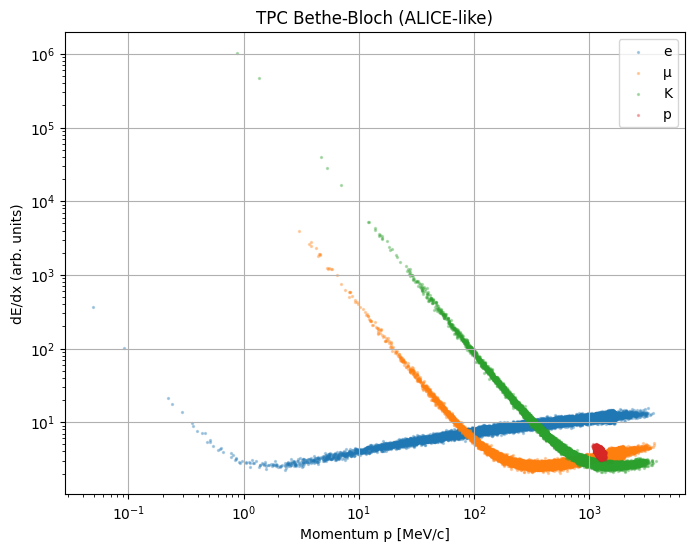

In [805]:
p, dedx, labels = compute_dedx(df)

plt.figure(figsize=(8,6))

# Plot per particle type
mask_e  = np.char.find(labels.astype(str), "ee") >= 0
mask_mu = np.char.find(labels.astype(str), "mumu") >= 0
mask_K  = np.char.find(labels.astype(str), "KK") >= 0
mask_p  = np.char.find(labels.astype(str), "pp") >= 0

plt.scatter(p[mask_e],  dedx[mask_e],  s=2, alpha=0.3, label="e")
plt.scatter(p[mask_mu], dedx[mask_mu], s=2, alpha=0.3, label="μ")
plt.scatter(p[mask_K],  dedx[mask_K],  s=2, alpha=0.3, label="K")
plt.scatter(p[mask_p],  dedx[mask_p],  s=2, alpha=0.3, label="p")

plt.xscale("log")
plt.xlabel("Momentum p [MeV/c]")
plt.ylabel("dE/dx (arb. units)")
plt.title("TPC Bethe-Bloch (ALICE-like)")
plt.legend()
plt.grid(True)
plt.yscale("log")

plt.show()

In [806]:
def build_tracks(df):
    tracks = []

    for i in [1, 2]:
        tmp = pd.DataFrame({
            "process": df["process"],
            "px": df[f"px{i}"],
            "py": df[f"py{i}"],
            "pz": df[f"pz{i}"],
        })

        tracks.append(tmp)

    tracks_df = pd.concat(tracks, ignore_index=True)

    return tracks_df

In [807]:
def assign_particle_type(tracks_df):
    tracks_df = tracks_df.copy()

    tracks_df["particle"] = "unknown"

    tracks_df.loc[tracks_df["process"].str.contains("ee"), "particle"] = "e"
    tracks_df.loc[tracks_df["process"].str.contains("mumu"), "particle"] = "mu"
    tracks_df.loc[tracks_df["process"].str.contains("KK"), "particle"] = "K"
    tracks_df.loc[tracks_df["process"].str.contains("pp"), "particle"] = "p"

    return tracks_df

In [808]:
def assign_mass_per_track(tracks_df):
    tracks_df = tracks_df.copy()

    mass_dict = {
        "e": masses["e"],
        "mu": masses["mu"],
        "K": masses["K"],
        "p": masses["p"]
    }

    tracks_df["mass"] = tracks_df["particle"].map(mass_dict)

    return tracks_df

In [809]:
def compute_dedx_tracks(tracks_df):
    tracks_df = tracks_df.copy()

    params = (5.0, 2.0, 3.0, 2.0, 0.6)

    px = tracks_df["px"].values
    py = tracks_df["py"].values
    pz = tracks_df["pz"].values
    m  = tracks_df["mass"].values

    p = np.sqrt(px**2 + py**2 + pz**2)

    beta_gamma = p / (m + 1e-12)
    beta_gamma = np.clip(beta_gamma, 0.05, None)

    dedx = bethe_bloch(beta_gamma, params)


    # smearing
    dedx *= np.random.lognormal(mean=0, sigma=0.06, size=len(dedx))

    tracks_df["p"] = p
    tracks_df["dedx"] = dedx

    return tracks_df

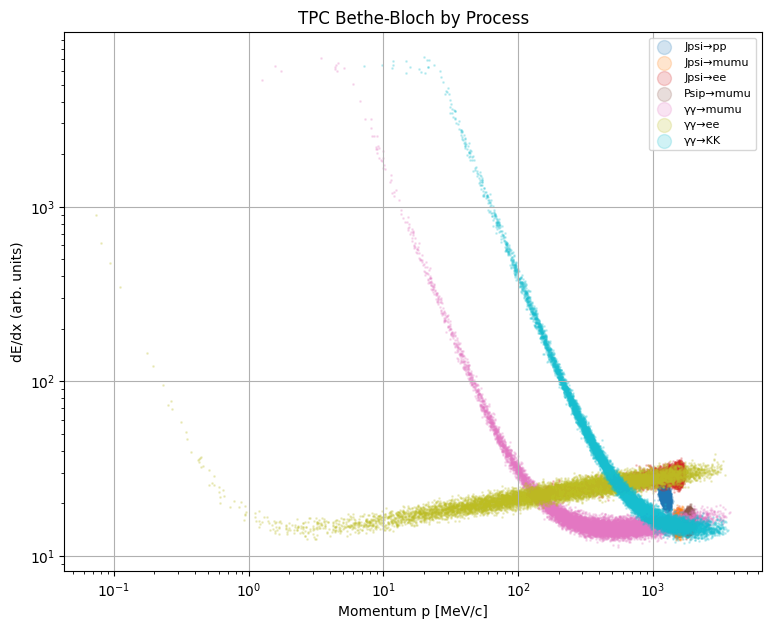

In [810]:
plt.figure(figsize=(9,7))

p_MeV = tracks_df["p"] * 1000

# get all unique processes
processes = tracks_df["process"].unique()

# use a colormap (auto handles many processes)
colors = plt.cm.tab10(np.linspace(0, 1, len(processes)))

for proc, color in zip(processes, colors):
    mask = tracks_df["process"] == proc

    plt.scatter(
        p_MeV[mask],
        tracks_df["dedx"][mask],
        s=1,
        alpha=0.2,
        label=proc,
        color=color
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Momentum p [MeV/c]")
plt.ylabel("dE/dx (arb. units)")
plt.title("TPC Bethe-Bloch by Process")

plt.legend(markerscale=10, fontsize=8)
plt.grid(True)

plt.show()